In [1]:
import TDD_scaled as TDDS
import time

In [2]:
# soft hard 
states = TDDS.generate_states(TDDS.N + 1)
len(states)

14188744

In [3]:
# A fastest, more difference
# Changed V_end for all 
# Added infeasibility rule for w
# N = 10, SCALE = 0.2, different scaling, DRS_RANGE = 0.5, t_drs not scaled, second discretize_g, delta = g_step, g_AB1 = -g_step, g_AC1 = -2 * g_step
# no scaling of lambda_pen, g_step = 0.4, g_min/max = (-)3.5

start = time.time()

U, pi_A, pi_BC, xA_star, xBC_star = TDDS.solve_DP(objective="simple")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^BC (mixed strategy):\n{pi_BC}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[0.5 0.9 0.5 0.9]
 [0.1 0.5 0.5 0.5]]
π^A (mixed strategy): 
[-0.  1.]
π^BC (mixed strategy):
[0. 0. 0. 1.]
Total runtime of the program is 23719.39671087265 seconds


In [4]:
TDDS.d0

{'A': 19.400000000000002, 'B': 19.560000000000002, 'C': 19.480000000000004}

In [4]:
# Simulation
stats = TDDS.run_simulations(U, pi_A, pi_BC, xA_star, xBC_star, n_sim=10000, objective="simple")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.0000
P(BC wins): 1.0000
Mean gap g_AB: 0.5000
Mean gap g_AC: -3.1000
Std gap g_AB: 0.0000
Std gap g_AC: 0.0000
Mean gap g_AB | A wins: 0.0000
Mean gap g_AC | A wins: 0.0000
Mean gap g_AB | BC wins: 0.5000
Mean gap g_AC | BC wins: -3.1000
Std gap g_AB | A wins: 0.0000
Std gap g_AC | A wins: 0.0000
Std gap g_AB | BC wins: 0.0000
Std gap g_AC | BC wins: 0.0000


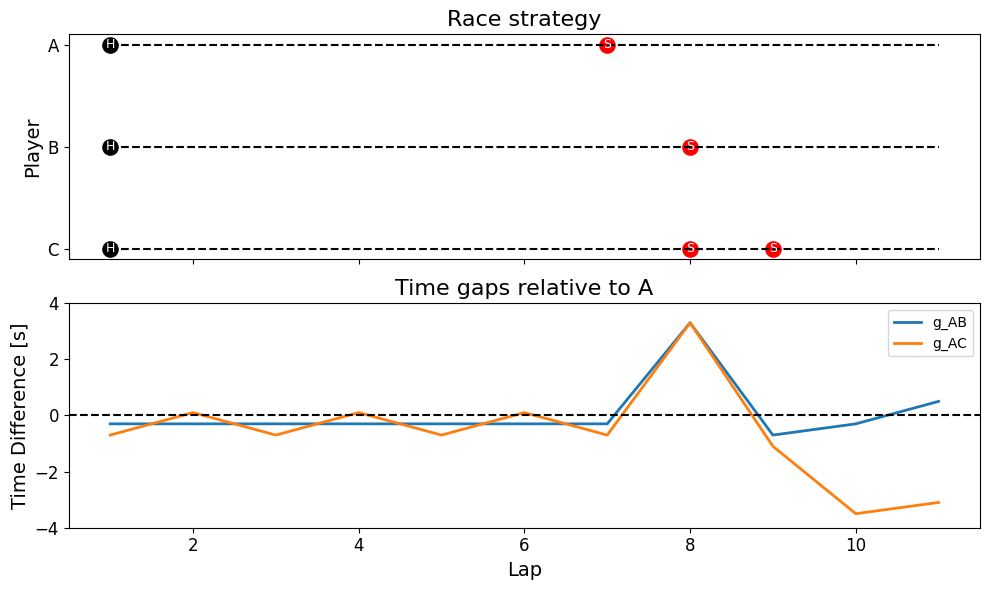

In [5]:
_, _, h, g, p = TDDS.simulate_race(pi_A, pi_BC, xA_star, xBC_star)
TDDS.plot_sample_path(h, g, p)

In [ ]:
# 10:17

In [1]:
import smG_scaled as smGS
import time

In [7]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

6176304

In [8]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="gap")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.62361229 -0.15979968]
 [-0.57358546 -0.66055776]]
π^A (mixed strategy): 
[0.15790611 0.84209389]
π^B (mixed strategy):
[0.90917176 0.09082824]
Total runtime of the program is 21923.88584780693 seconds


In [9]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="gap")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7534
P(B wins): 0.2466
P(tie): 0.0000
Mean gap: -0.5977
Std gap: 0.7856
Mean gap | A wins: -0.9371
Mean gap | B wins: 0.4391
Std gap | A wins: 0.5489
Std gap | B wins: 0.3940


Winner: A
Gap: -2.1999999999999975
Winner: A
Gap: -0.9999999999999964


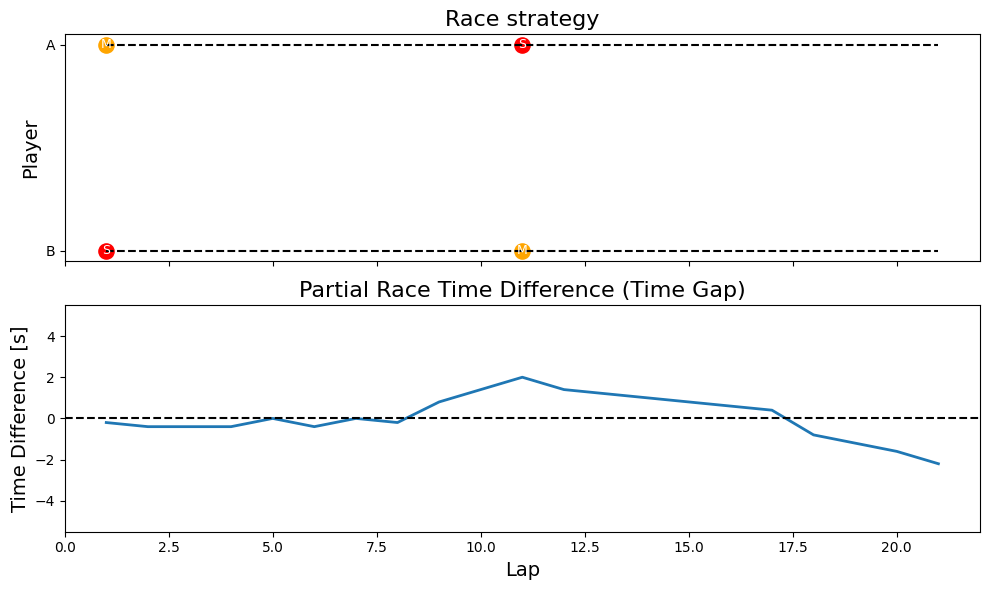

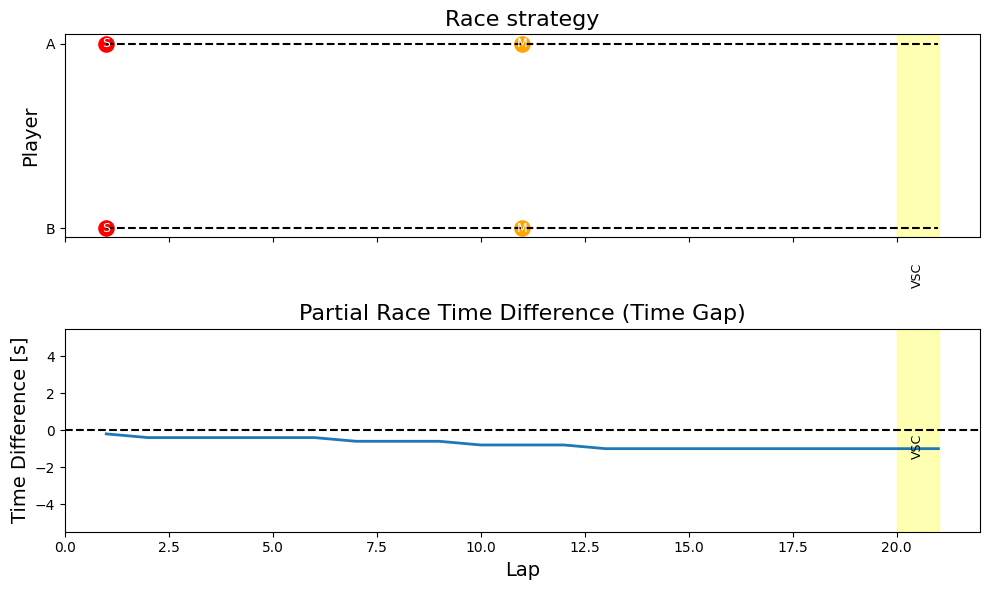

In [10]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [ ]:
# 17:15

In [ ]:
# SAVE THE POLICIES

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.20000000000000462


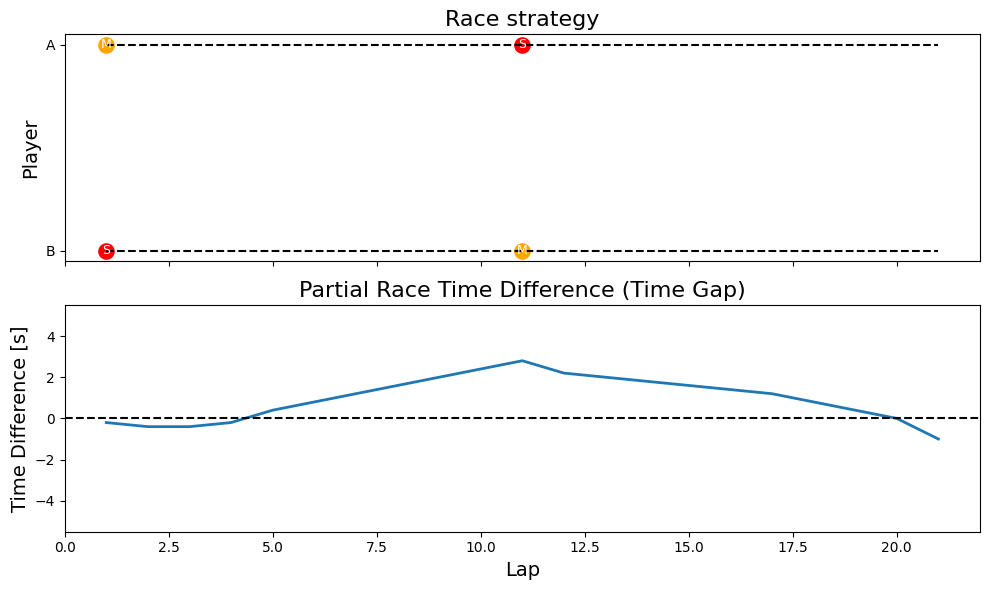

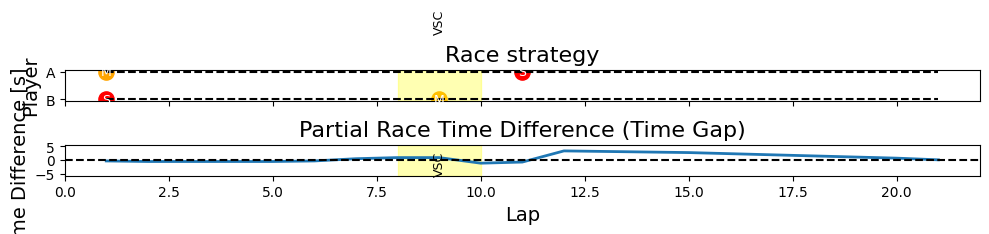

In [11]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -2.3999999999999977
Winner: B
Gap: 0.600000000000005


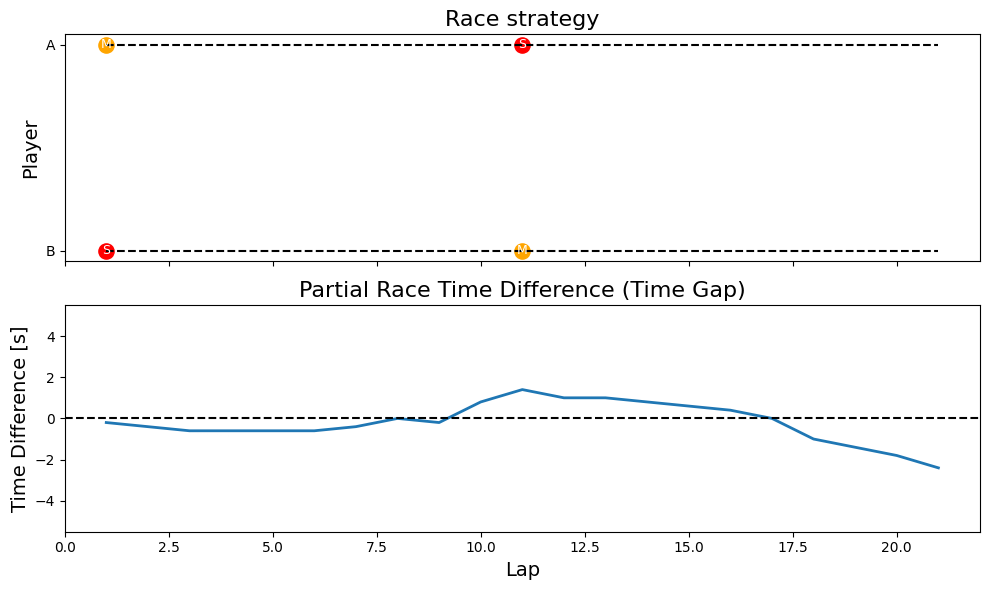

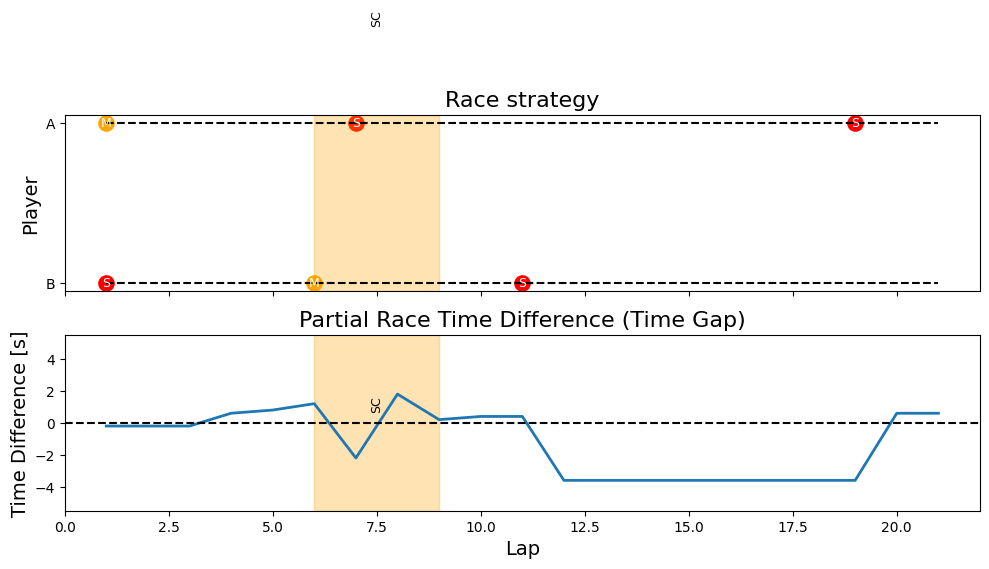

In [12]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.19999999999999574
Winner: B
Gap: 0.600000000000005


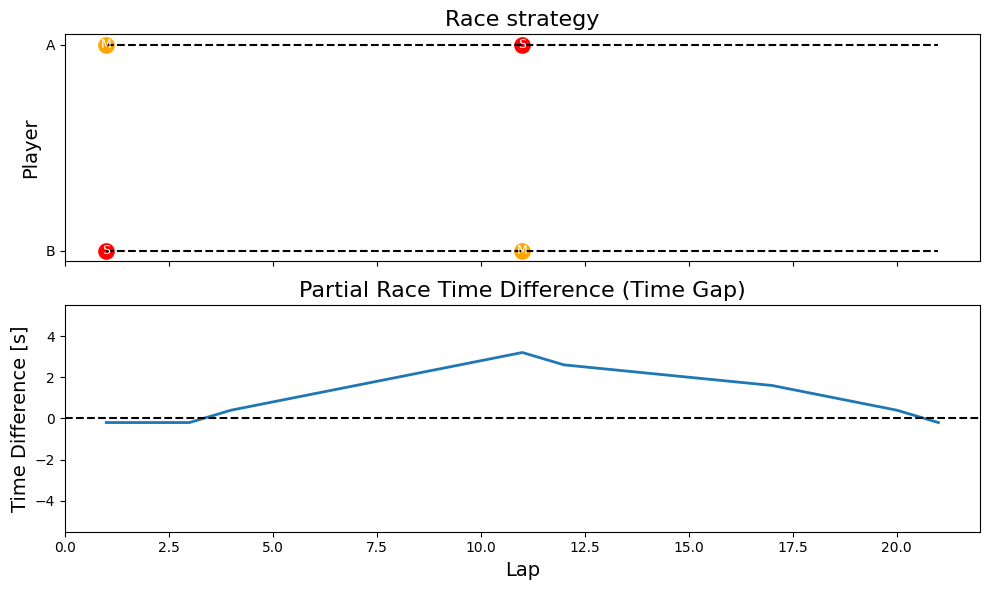

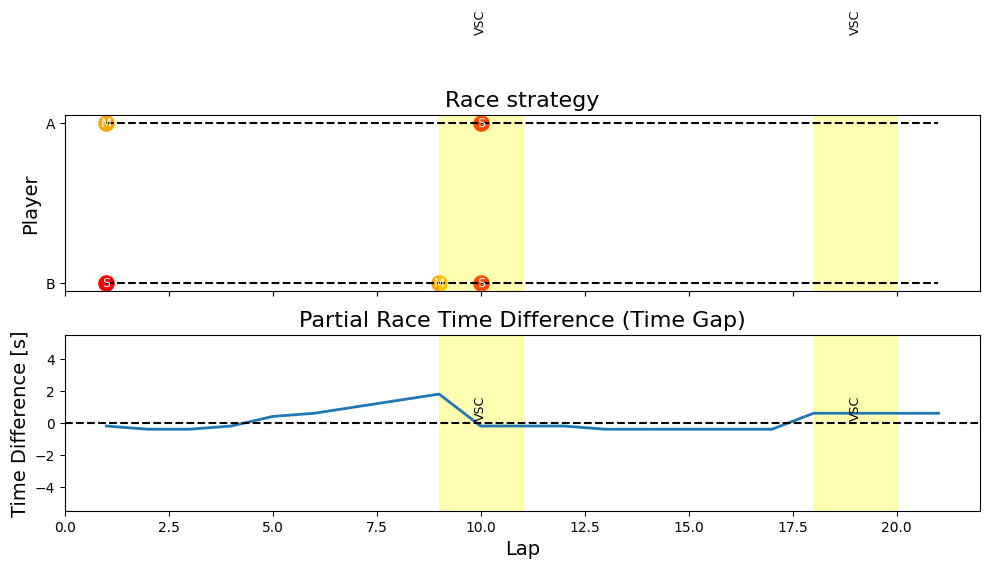

In [14]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.7999999999999963
Winner: A
Gap: -0.7999999999999963


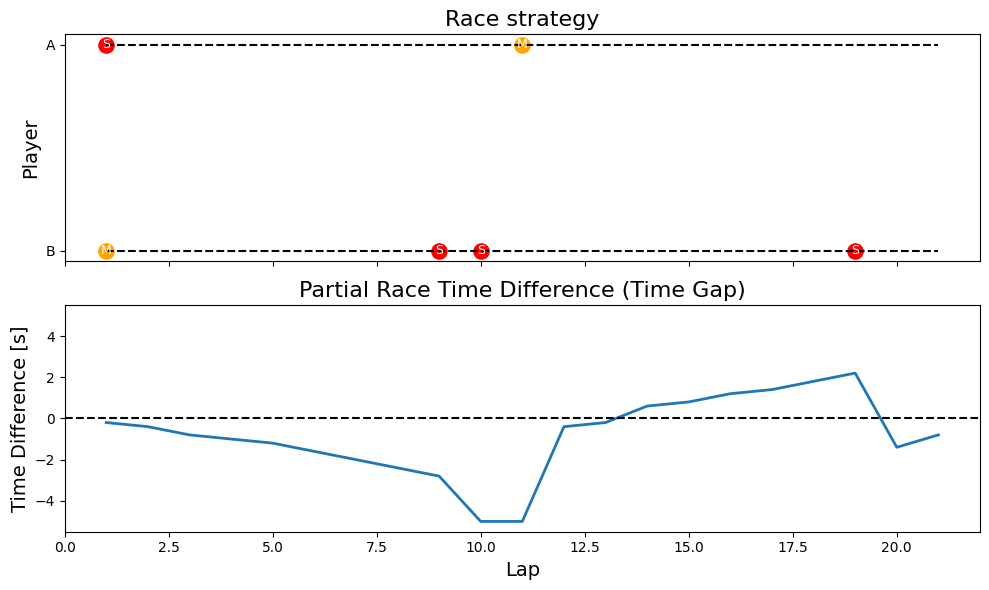

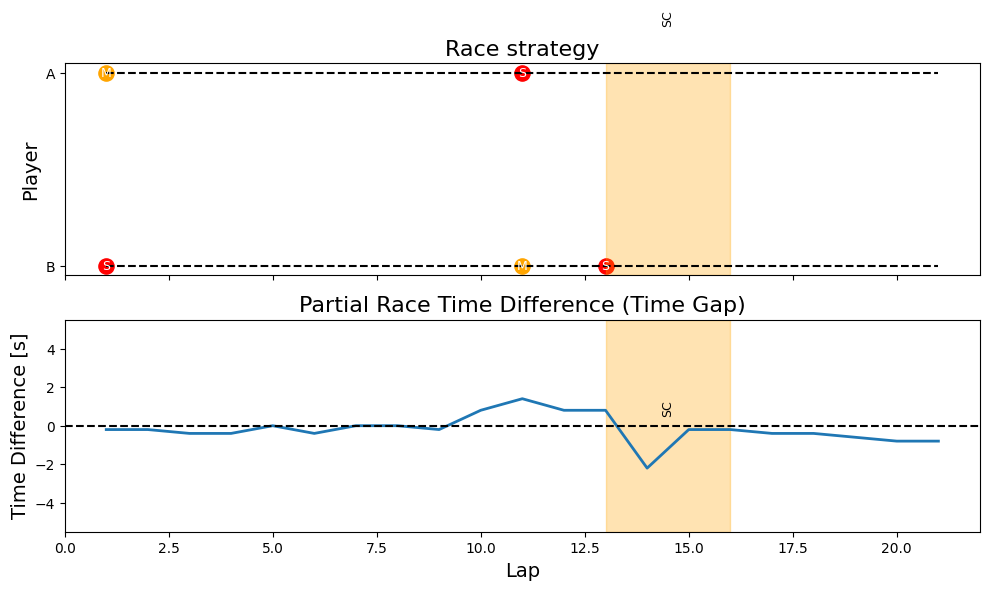

In [17]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="gap")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [2]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
states = smGS.generate_states(smGS.N + 1)
len(states)

6176304

In [3]:
# Changed V_end for gap 
# Added infeasibility rule for w
# N = 20, 2 values for RVs, Scale = 0.2, g_step = 0.2, g_min/max = (-)5.0, no scaling of TDRS, second discretize_g, DRS_RANGE = 0.5
# delta = g_step, g1 = -g_step, SC_gap = g_step
# Soft and Hard tires
# Larger Z and TDR values
start = time.time()

U, pi_A, pi_B, xA_star, xB_star = smGS.solve_SDP(objective="win")
print(f"Payoff matrix U': \n{U}")
print(f"π^A (mixed strategy): \n{pi_A}")
print(f"π^B (mixed strategy):\n{pi_B}")

time.sleep(1)
end = time.time()

print(f"Total runtime of the program is {end - start} seconds")

Payoff matrix U': 
[[-0.52766338 -0.31044165]
 [-0.42759929 -0.53636827]]
π^A (mixed strategy): 
[0.33365669 0.66634331]
π^B (mixed strategy):
[0.69304619 0.30695381]
Total runtime of the program is 21094.439959049225 seconds


In [4]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="win")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7355
P(B wins): 0.2645
P(tie): 0.0000
Mean gap: -1.0053
Std gap: 1.8991
Mean gap | A wins: -1.7408
Mean gap | B wins: 1.0398
Std gap | A wins: 1.5268
Std gap | B wins: 1.2113


Winner: A
Gap: -1.9999999999999973
Winner: A
Gap: -0.5999999999999961


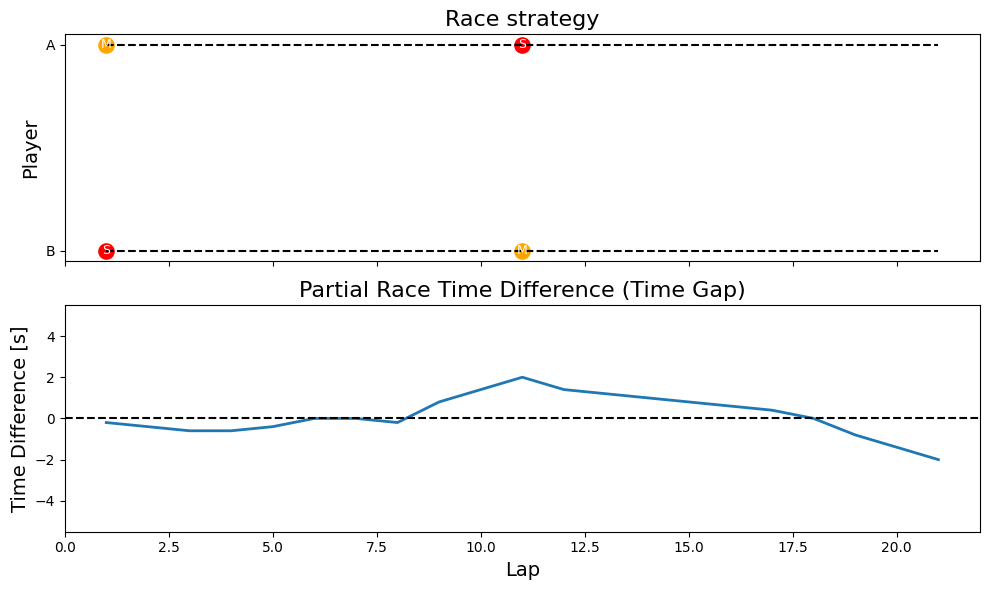

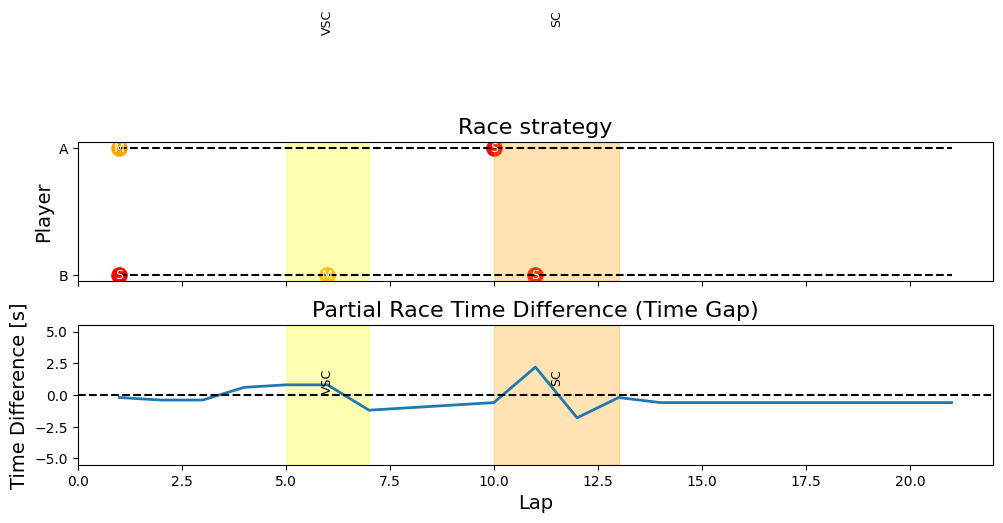

In [5]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.9999999999999964
Winner: B
Gap: 0.8000000000000052


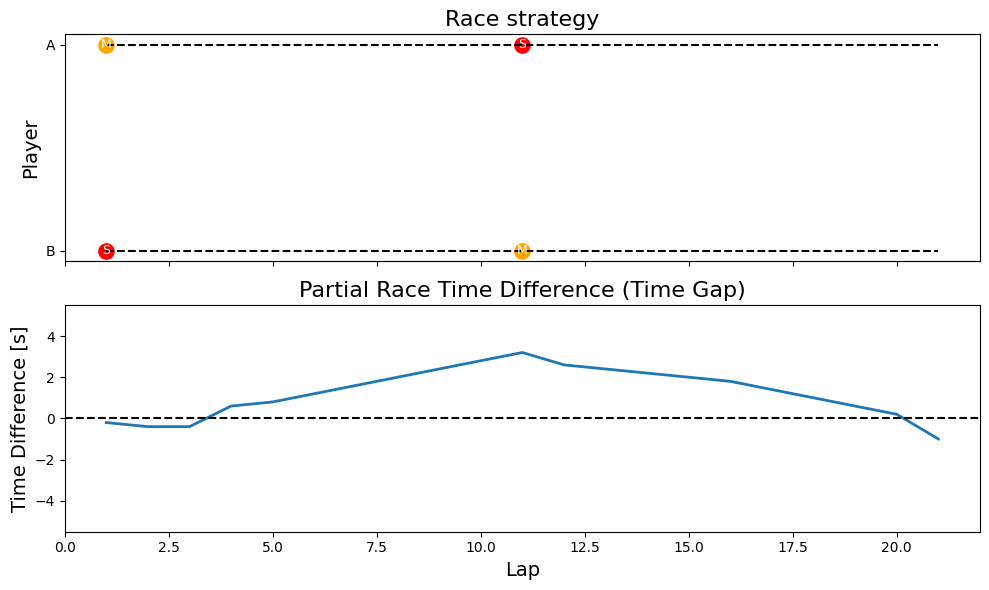

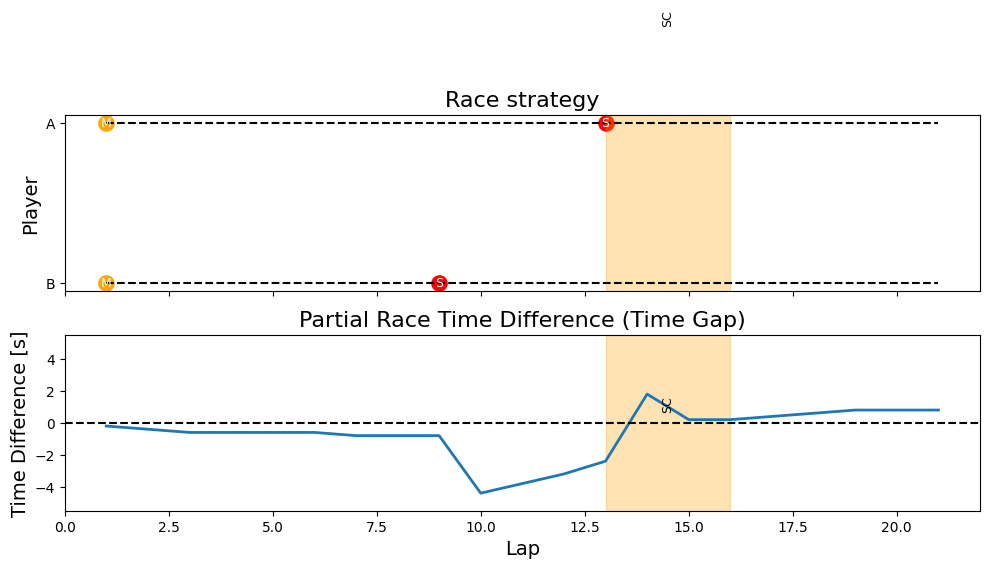

In [6]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -3.999999999999999
Winner: B
Gap: 0.20000000000000462


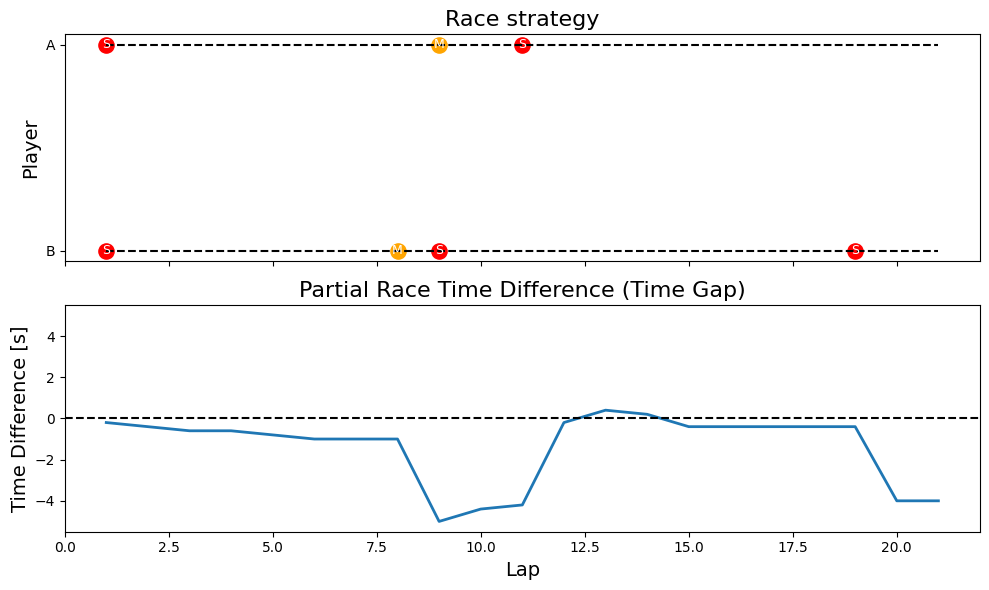

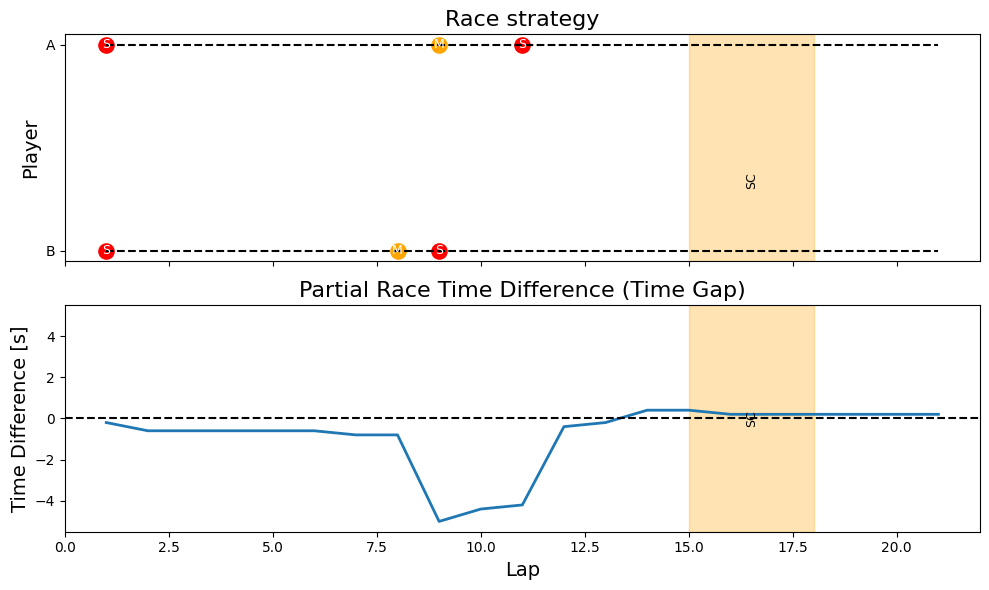

In [7]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

In [8]:
# Simulation 
stats = smGS.run_simulations(U, pi_A, pi_B, xA_star, xB_star, n_sim=10000, objective="win")

for k, v in stats.items():
    print(f"{k}: {v:.4f}")

P(A wins): 0.7301
P(B wins): 0.2699
P(tie): 0.0000
Mean gap: -1.0356
Std gap: 1.9313
Mean gap | A wins: -1.7947
Mean gap | B wins: 1.0179
Std gap | A wins: 1.5575
Std gap | B wins: 1.2175


Winner: A
Gap: -0.19999999999999574
Winner: A
Gap: -5.0


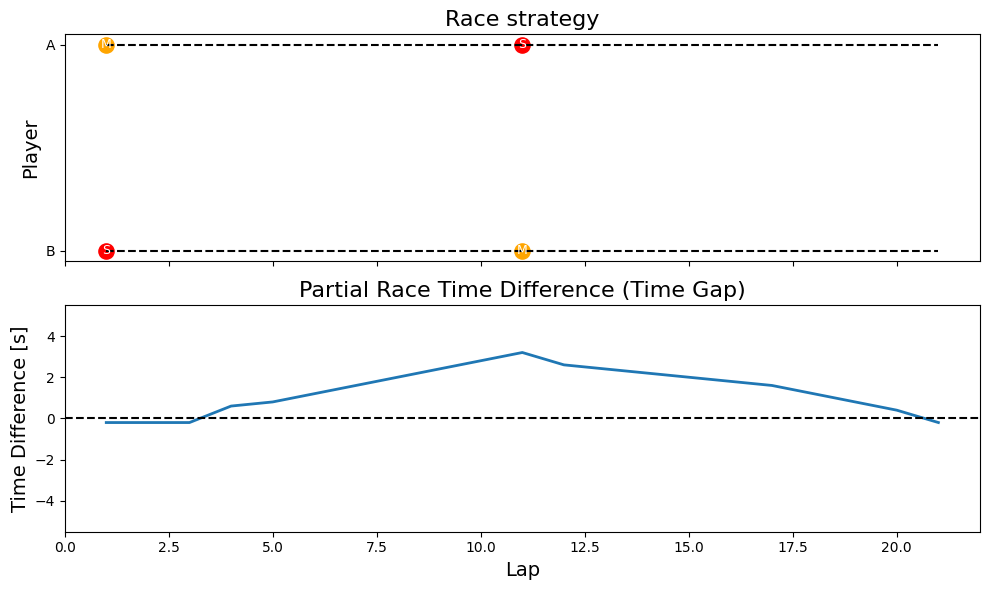

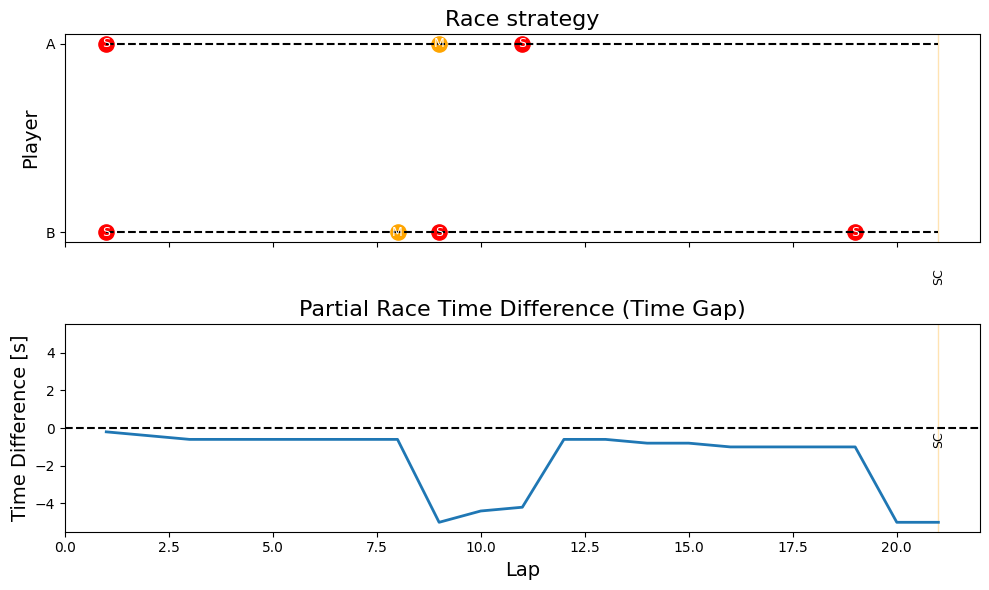

In [9]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.19999999999999574
Winner: B
Gap: 4.800000000000009


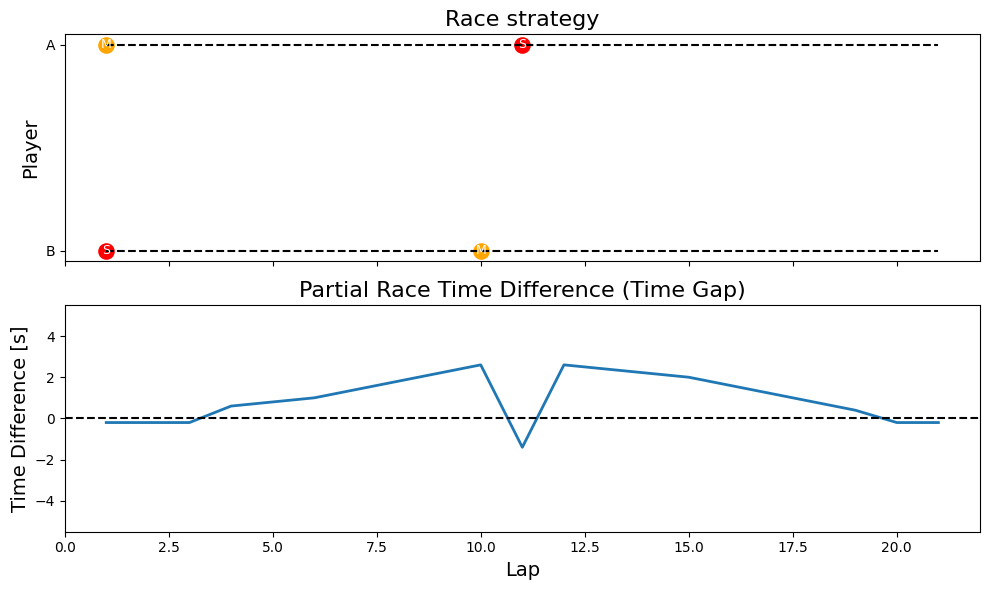

/Users/elevels/Documents/UM/Bachelor/Year 3/Thesis/Code/Thesis-F1-Pit-Stop-Optimization/smG_scaled.py:745: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


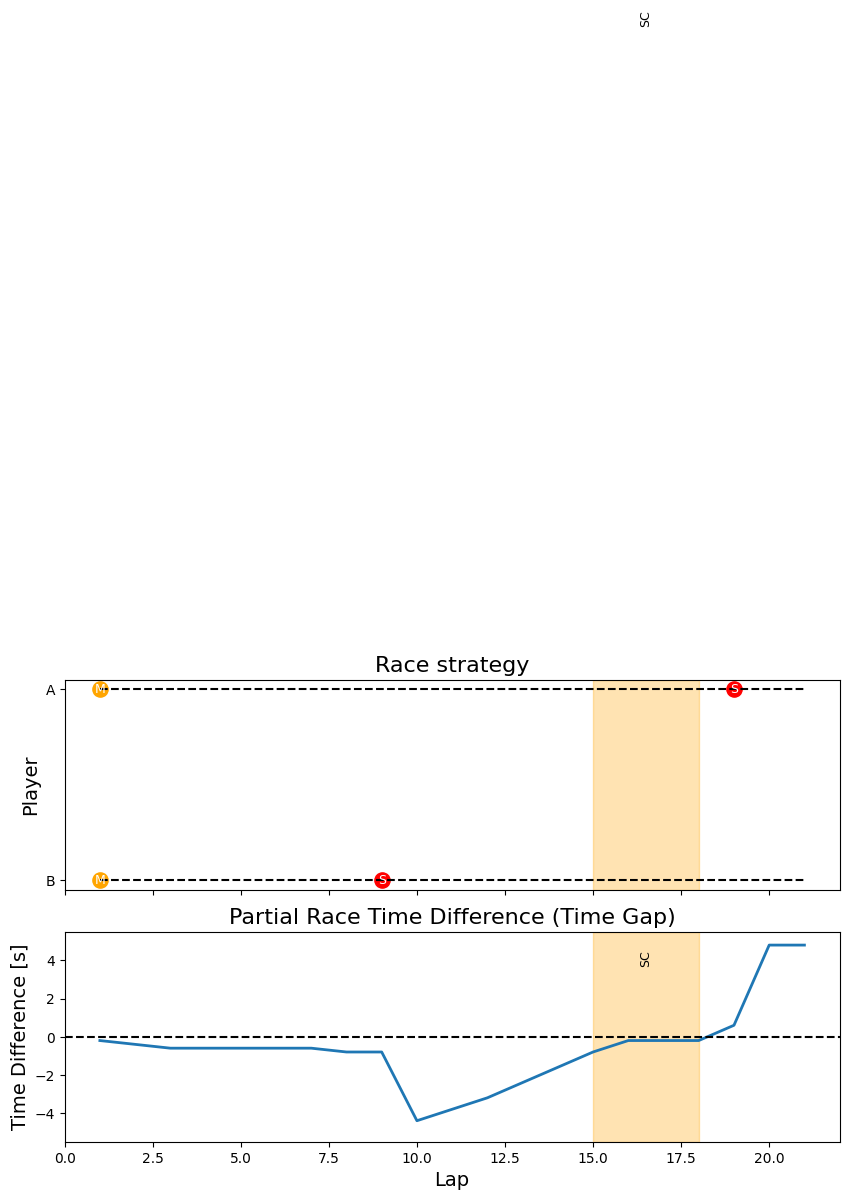

In [10]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -0.7999999999999963
Winner: A
Gap: -2.3999999999999977


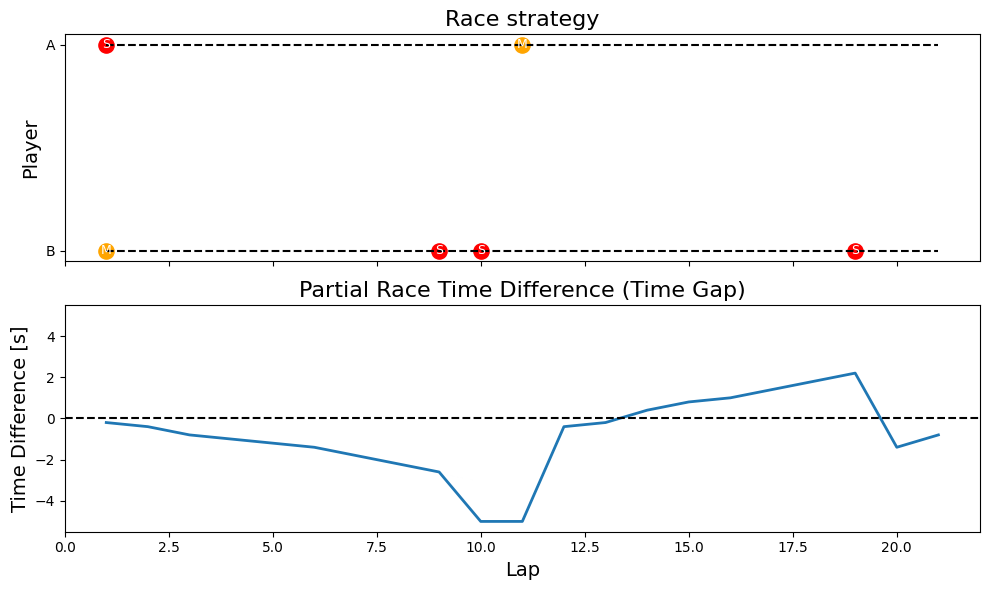

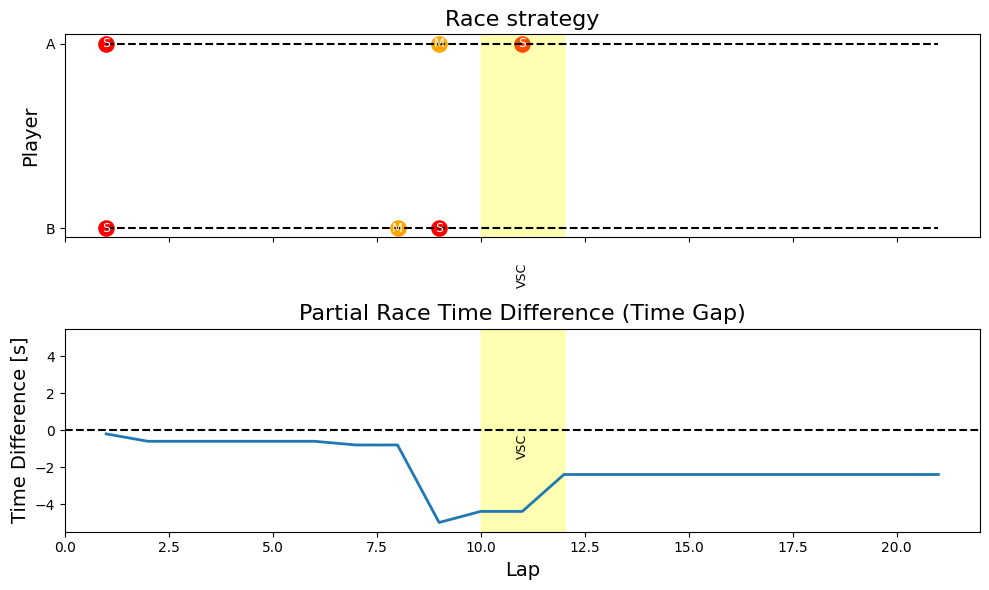

In [11]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)

Winner: A
Gap: -1.599999999999997
Winner: A
Gap: -1.7999999999999972


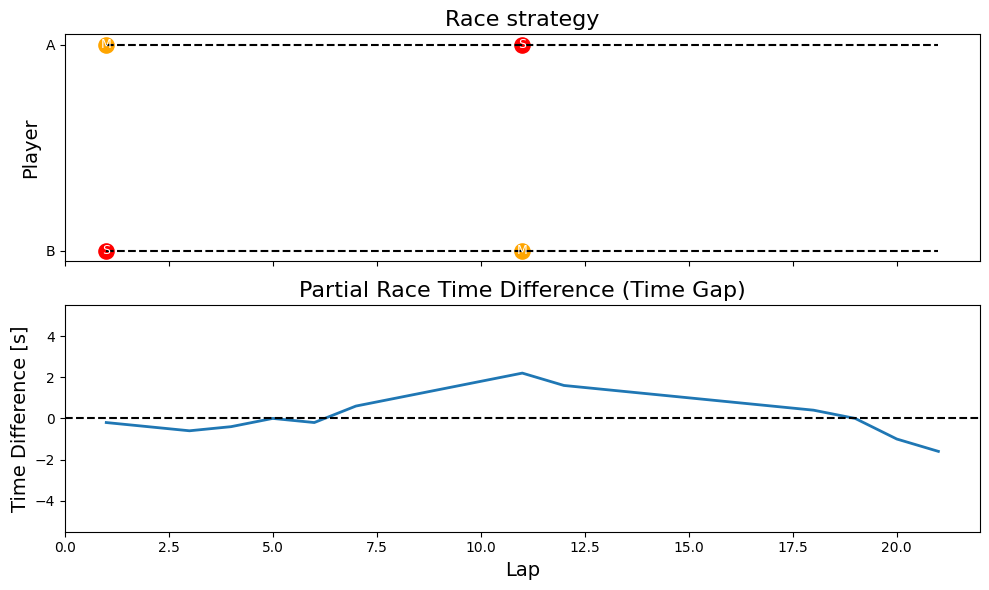

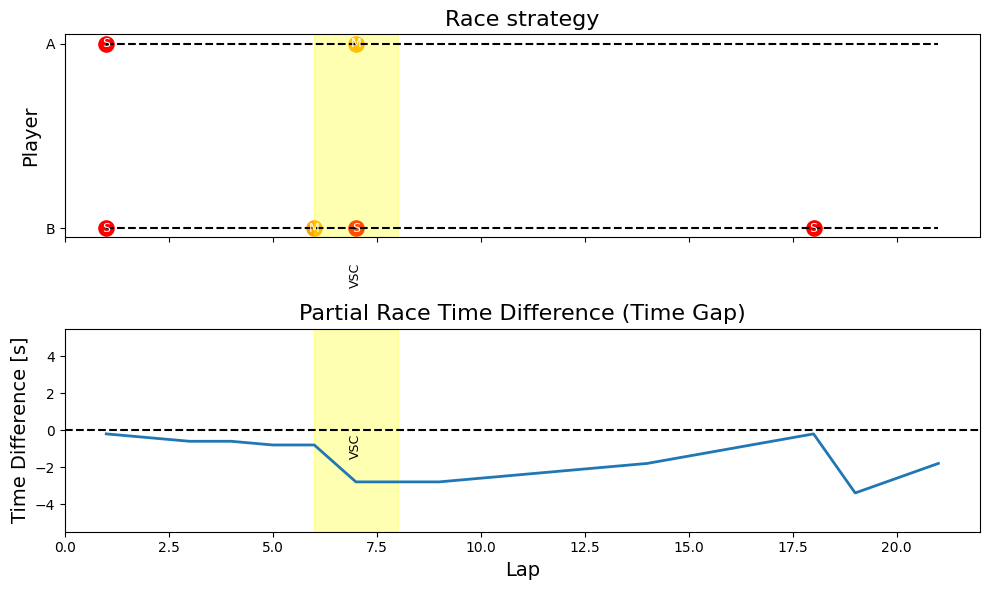

In [12]:
h_noY, g_noY, y_noY, p_noY = smGS.get_sample_no_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")
h_VSC, g_VSC, y_VSC_hist, p_VSC = smGS.get_sample_with_yellow(pi_A, pi_B, xA_star, xB_star, objective="win")

smGS.plot_sample_path(h_noY, g_noY, y_noY, p_noY)
smGS.plot_sample_path(h_VSC, g_VSC, y_VSC_hist, p_VSC)